In [13]:
import pandas as pd
from pathlib import Path
import torch

In [14]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [15]:
import tarfile
import urllib.request

In [22]:
def download_and_extract_rider_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents = True, exist_ok = True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as ridership_tarball:
            ridership_tarball.extractall(path="datasets", filter = "data")

In [23]:
download_and_extract_rider_data()

In [24]:
path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")

In [26]:
df = pd.read_csv(path, parse_dates=["service_date"])
df.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


In [27]:
df.columns = ["date", "day_type", "bus", "rail", "total"]

In [34]:
df = df.drop(["total"], axis = 1)

In [35]:
df = df.sort_values("date").set_index("date")

KeyError: "None of ['date'] are in the columns"

In [36]:
df = df.drop_duplicates()

In [37]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


In [38]:
df["day_type"].value_counts()

day_type
W    5336
U    1216
A    1087
Name: count, dtype: int64

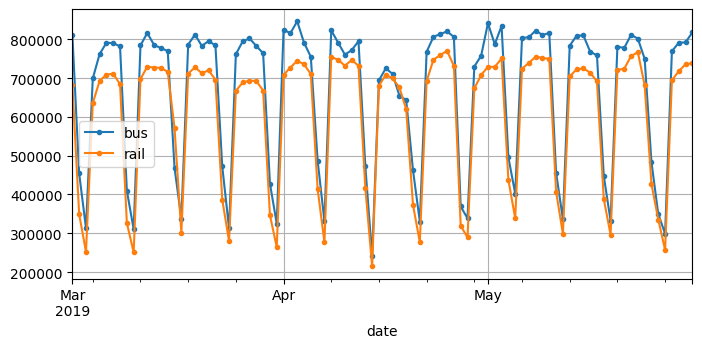

In [39]:
import matplotlib.pyplot as plt

df["2019-03" : "2019-05"].plot(grid = True, marker = ".", figsize=(8,3.5))
plt.show()

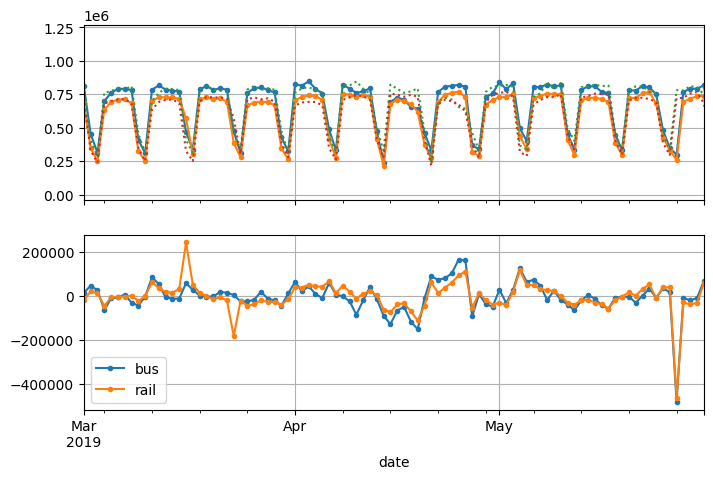

In [42]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03" : "2019-05"]

fig, axs = plt.subplots(2, 1, figsize = (8,5), sharex = True)
df.plot(ax = axs[0], legend=False, marker = ".")
df.shift(7).plot(ax=axs[0], legend=False, grid=True, linestyle = ":")
diff_7.plot(ax = axs[1], grid = True, marker = ".")
plt.show()

In [44]:
df.loc["2019-05-25" : "2019-05-28"]["day_type"]

date
2019-05-25    A
2019-05-26    U
2019-05-27    U
2019-05-28    W
Name: day_type, dtype: str

In [45]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [52]:
targets = df[["bus", "rail"]]["2019-03" : "2019-05"]

In [53]:
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

In [57]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample("ME").mean()

In [58]:
df_monthly

,bus,rail
date,,
2001-01-31,807190.580645,474591.419355
2001-02-28,848889.000000,488188.178571
2001-03-31,865392.419355,498825.096774
2001-04-30,835126.366667,490444.533333
2001-05-31,862701.419355,507862.258065
...,...,...
2021-07-31,342101.096774,257660.193548
2021-08-31,353215.516129,260038.548387
2021-09-30,401958.833333,299608.366667


In [64]:
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

In [65]:
rolling_average_12_months

,bus,rail
date,,
2001-01-31,NaN,NaN
2001-02-28,NaN,NaN
2001-03-31,NaN,NaN
2001-04-30,NaN,NaN
2001-05-31,NaN,NaN
...,...,...
2019-08-31,653301.645533,605589.250966
2019-09-30,653812.309421,603990.406522
2019-10-31,651295.035228,601386.350070


[]

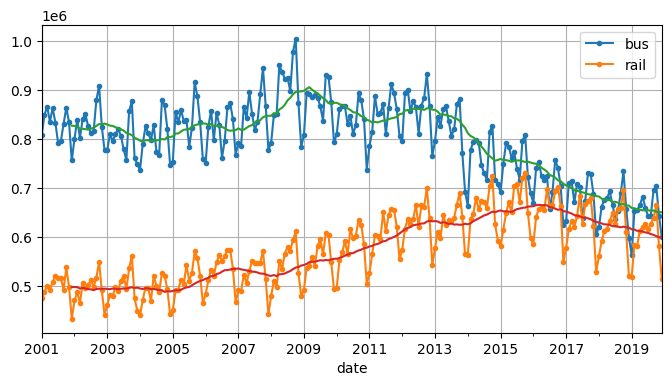

In [69]:
fig, axs = plt.subplots(figsize = (8,4))
df_monthly[period].plot(ax = axs, grid = True, marker = ".")
rolling_average_12_months.plot(ax = axs, grid = True, legend=False)
plt.plot()

<Axes: xlabel='date'>

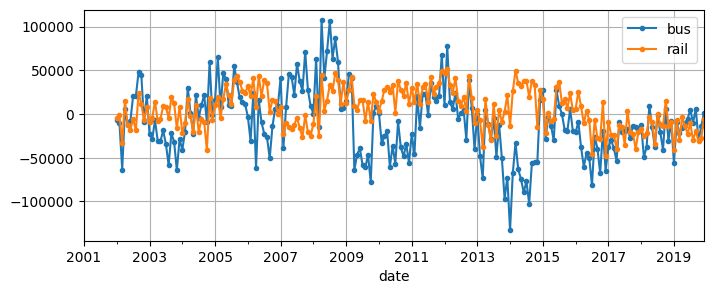

In [72]:
df_monthly.diff(12)[period].plot(grid=True, marker = ".", figsize = (8,3))

In [73]:
diff_12 = df_monthly.diff(12)[period]

In [74]:
diff_12

,bus,rail
date,,
2001-01-31,NaN,NaN
2001-02-28,NaN,NaN
2001-03-31,NaN,NaN
2001-04-30,NaN,NaN
2001-05-31,NaN,NaN
...,...,...
2019-08-31,-9726.806452,-29745.967742
2019-09-30,6127.966667,-19186.133333
2019-10-31,-30207.290323,-31248.677419


In [75]:
diff_12.abs().mean()

bus     31448.673327
rail    19957.834066
dtype: float64

In [77]:
targets = df_monthly[["bus", "rail"]][period]
(diff_12 / targets).abs().mean()

bus     0.039674
rail    0.034511
dtype: float64

In [78]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.6 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.6 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.6 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.6 MB 1.0 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.6 MB 999.9 kB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.6 MB 999.9 kB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.6 MB 999.9 kB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.6 MB 850.9 kB/s eta 0:00:10
   -------- ------------------------------- 2.1/9.6 MB 835.3 kB/s eta 0:00:09
   -------- -----------

In [79]:
from statsmodels.tsa.arima.model import ARIMA

In [80]:
origin, today = "2019-01-01", "2019-05-31"
rail_series  = df.loc[origin:today]["rail"].asfreq("D")

In [81]:
rail_series

date
2019-01-01    245852
2019-01-02    573542
2019-01-03    627781
2019-01-04    628514
2019-01-05    348257
               ...  
2019-05-27    256757
2019-05-28    694292
2019-05-29    717681
2019-05-30    735508
2019-05-31    738322
Freq: D, Name: rail, Length: 151, dtype: int64

In [88]:
model = ARIMA(rail_series, order = (1,0,0), seasonal_order=(0,1,1,7))
model = model.fit()
y_pred = model.forecast()

In [89]:
y_pred

2019-06-01    427758.626221
Freq: D, dtype: float64

In [93]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
rail_series = df.loc[origin : end_date]["rail"].asfreq("D")
y_pred = []

time_series = pd.date_range(start_date, end_date)
for today in time_series.shift(-1):
    model = ARIMA(rail_series[origin:today], order = (1,0,0), seasonal_order=(0,1,1,7))
    model = model.fit()
    y_forecased = model.forecast().iloc[0]
    y_pred.append(y_forecased)
y_preds = pd.Series(y_pred, time_series)
mae = (y_preds - rail_series[time_series]).abs().mean()

In [94]:
mae

np.float64(32040.720100852956)

In [102]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window):
        self.series = series
        self.window = window
    
    def __len__(self):
        return len(self.series) - self.window
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError()
        end = idx + self.window
        window = self.series[idx : end]
        target = self.series[end]
        return window, target

In [98]:
df["rail"]

date
2001-01-01    126455
2001-01-02    501952
2001-01-03    536432
2001-01-04    550011
2001-01-05    557917
               ...  
2021-11-26    189694
2021-11-27    187065
2021-11-28    147830
2021-11-29    276090
2021-11-30    302349
Name: rail, Length: 7639, dtype: int64

In [101]:
df[["rail"]]["2019-01-01":"2019-03-01"].values

array([[245852],
       [573542],
       [627781],
       [628514],
       [348257],
       [260556],
       [662470],
       [701693],
       [685444],
       [690162],
       [679115],
       [325219],
       [250222],
       [705571],
       [720095],
       [728048],
       [734929],
       [700006],
       [312424],
       [236744],
       [401503],
       [712125],
       [718899],
       [711300],
       [590674],
       [296063],
       [221081],
       [678810],
       [579917],
       [ 97917],
       [243912],
       [648091],
       [345650],
       [250724],
       [718764],
       [734181],
       [727769],
       [732351],
       [655823],
       [338847],
       [251192],
       [704667],
       [698387],
       [728764],
       [746611],
       [687932],
       [362613],
       [256817],
       [519409],
       [725195],
       [717172],
       [727504],
       [702988],
       [328179],
       [240478],
       [680844],
       [699462],
       [711827],
       [714700

In [107]:
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

In [108]:
from torch.utils.data import DataLoader

window_length = 56
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [109]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs, patience=10, factor=0.1):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=patience, factor=factor)
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        scheduler.step(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [110]:
import torch.nn as nn
import torchmetrics

torch.manual_seed(42)
model = nn.Sequential(nn.Flatten(), nn.Linear(window_length, 1)).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(model, optimizer, loss_fn, metric, train_loader,
                valid_loader, n_epochs=50)

Epoch 1/50, train loss: 0.0154, train metric: 0.1458, valid metric: 0.1235
Epoch 2/50, train loss: 0.0100, train metric: 0.1117, valid metric: 0.0996
Epoch 3/50, train loss: 0.0075, train metric: 0.0933, valid metric: 0.0795
Epoch 4/50, train loss: 0.0063, train metric: 0.0816, valid metric: 0.0668
Epoch 5/50, train loss: 0.0056, train metric: 0.0741, valid metric: 0.0609
Epoch 6/50, train loss: 0.0053, train metric: 0.0697, valid metric: 0.0550
Epoch 7/50, train loss: 0.0049, train metric: 0.0663, valid metric: 0.0545
Epoch 8/50, train loss: 0.0047, train metric: 0.0636, valid metric: 0.0493
Epoch 9/50, train loss: 0.0045, train metric: 0.0617, valid metric: 0.0457
Epoch 10/50, train loss: 0.0045, train metric: 0.0615, valid metric: 0.0437
Epoch 11/50, train loss: 0.0043, train metric: 0.0586, valid metric: 0.0453
Epoch 12/50, train loss: 0.0042, train metric: 0.0577, valid metric: 0.0420
Epoch 13/50, train loss: 0.0042, train metric: 0.0576, valid metric: 0.0403
Epoch 14/50, train lo

In [112]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),
            nn.Tanh()
        )
        self.output_layer = nn.Linear(hidden_size, output_size)
    def forward(self, X):
        batch_size, window_length, dim = X.shape
        X_transform = X.transform(0,1)
        H = torch.zeros(batch_size, self.hidden_size, device="cuda")
        for Xt in X_transform:
            XH = torch.cat((Xt, H), dim = 1)
            H = self.memory_cell(XH)
        return self.output_layer(H)

In [116]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, output_size)
    def forward(self, X):
        outputs, last_hidden = self.rnn(X)
        return self.output_layer(outputs[: , -1])

In [117]:
def fit_and_evaluate(model, train_loader, valid_loader, lr, n_epochs=50,
                     patience=20, factor=0.1):
    loss_fn = nn.HuberLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
    metric = torchmetrics.MeanAbsoluteError().to(device)
    history = train(model, optimizer, loss_fn, metric,
                    train_loader, valid_loader, n_epochs=n_epochs,
                    patience=patience, factor=factor)
    return min(history["valid_metrics"]) * 1e6

In [118]:
torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)
univar_model = univar_model.to(device)
fit_and_evaluate(univar_model, train_loader, valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0487, train metric: 0.2535, valid metric: 0.1329
Epoch 2/50, train loss: 0.0181, train metric: 0.1523, valid metric: 0.1268
Epoch 3/50, train loss: 0.0137, train metric: 0.1459, valid metric: 0.1377
Epoch 4/50, train loss: 0.0122, train metric: 0.1348, valid metric: 0.1184
Epoch 5/50, train loss: 0.0115, train metric: 0.1279, valid metric: 0.1255
Epoch 6/50, train loss: 0.0105, train metric: 0.1231, valid metric: 0.1130
Epoch 7/50, train loss: 0.0090, train metric: 0.1127, valid metric: 0.1018
Epoch 8/50, train loss: 0.0064, train metric: 0.0885, valid metric: 0.0781
Epoch 9/50, train loss: 0.0055, train metric: 0.0792, valid metric: 0.0682
Epoch 10/50, train loss: 0.0048, train metric: 0.0727, valid metric: 0.0662
Epoch 11/50, train loss: 0.0044, train metric: 0.0683, valid metric: 0.0585
Epoch 12/50, train loss: 0.0043, train metric: 0.0675, valid metric: 0.0618
Epoch 13/50, train loss: 0.0043, train metric: 0.0662, valid metric: 0.0691
Epoch 14/50, train lo

30659.474432468414

In [125]:
class DeepRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.memory_cell = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.outout_layer = nn.Linear(hidden_size, output_size)
    
    def forward(self, X):
        outputs, last_time_step_for_layers = self.memory_cell(X)
        return self.outout_layer(outputs[:, -1])

In [126]:
torch.manual_seed(42)
deep_model = DeepRnnModel(
    input_size=1, hidden_size=32, output_size=1, num_layers=3).to(device)
fit_and_evaluate(deep_model, train_loader, valid_loader, lr=0.07, n_epochs=50)

Epoch 1/50, train loss: 0.0633, train metric: 0.2830, valid metric: 0.2212
Epoch 2/50, train loss: 0.0189, train metric: 0.1573, valid metric: 0.0951
Epoch 3/50, train loss: 0.0083, train metric: 0.0963, valid metric: 0.1044
Epoch 4/50, train loss: 0.0066, train metric: 0.0869, valid metric: 0.0621
Epoch 5/50, train loss: 0.0053, train metric: 0.0738, valid metric: 0.0718
Epoch 6/50, train loss: 0.0051, train metric: 0.0727, valid metric: 0.0686
Epoch 7/50, train loss: 0.0052, train metric: 0.0741, valid metric: 0.0552
Epoch 8/50, train loss: 0.0057, train metric: 0.0791, valid metric: 0.0969
Epoch 9/50, train loss: 0.0045, train metric: 0.0666, valid metric: 0.0670
Epoch 10/50, train loss: 0.0044, train metric: 0.0639, valid metric: 0.0464
Epoch 11/50, train loss: 0.0039, train metric: 0.0588, valid metric: 0.0397
Epoch 12/50, train loss: 0.0038, train metric: 0.0585, valid metric: 0.0535
Epoch 13/50, train loss: 0.0035, train metric: 0.0537, valid metric: 0.0450
Epoch 14/50, train lo

29384.944587945938

In [158]:
df_mulvar = df[["rail", "bus"]] / 1e6

In [159]:
df_mulvar["next_day_type"] = df[["day_type"]].shift(-1)

In [160]:
df_mulvar = pd.get_dummies(df_mulvar, dtype=float)

In [161]:
df_mulvar

,rail,bus,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.126455,0.297192,0.0,0.0,1.0
2001-01-02,0.501952,0.780827,0.0,0.0,1.0
2001-01-03,0.536432,0.824923,0.0,0.0,1.0
2001-01-04,0.550011,0.870021,0.0,0.0,1.0
2001-01-05,0.557917,0.890426,1.0,0.0,0.0
...,...,...,...,...,...
2021-11-26,0.189694,0.257700,1.0,0.0,0.0
2021-11-27,0.187065,0.237839,0.0,1.0,0.0
2021-11-28,0.147830,0.184817,0.0,0.0,1.0


In [168]:
mulvar_train = torch.FloatTensor(df_mulvar["2016-01" : "2018-12"].values)
mulvar_valid = torch.FloatTensor(df_mulvar["2019-01" : "2019-05"].values)
mulvar_test = torch.FloatTensor(df_mulvar["2019-06" : ].values)

In [169]:
class MulVarTimeSeriesDataset(nn.Module):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length
    def __len__(self):
        return len(self.series) - self.window_length
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("Out of Bounds")
        end = idx + self.window_length
        window = self.series[idx:end]
        target = self.series[end]
        return window, target[:1]

In [170]:
mulvar_train_set = MulVarTimeSeriesDataset(mulvar_train, window_length)
mulvar_valid_set = MulVarTimeSeriesDataset(mulvar_valid, window_length)
mulvar_test_set = MulVarTimeSeriesDataset(mulvar_test, window_length)

In [171]:
mulvar_train_loader = DataLoader(mulvar_train_set, batch_size=32, shuffle=True)
mulvar_valid_loader = DataLoader(mulvar_valid_set, batch_size=32)
mulvar_test_loader = DataLoader(mulvar_test_set, batch_size = 32)

In [172]:
torch.manual_seed(42)
mulvar_model = SimpleRnnModel(input_size=5, hidden_size=32, output_size=1)
mulvar_model = mulvar_model.to(device)

In [173]:
fit_and_evaluate(mulvar_model, mulvar_train_loader, mulvar_valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0652, train metric: 0.2960, valid metric: 0.0527
Epoch 2/50, train loss: 0.0076, train metric: 0.1007, valid metric: 0.0425
Epoch 3/50, train loss: 0.0028, train metric: 0.0558, valid metric: 0.0313
Epoch 4/50, train loss: 0.0018, train metric: 0.0410, valid metric: 0.0359
Epoch 5/50, train loss: 0.0017, train metric: 0.0383, valid metric: 0.0381
Epoch 6/50, train loss: 0.0015, train metric: 0.0368, valid metric: 0.0365
Epoch 7/50, train loss: 0.0014, train metric: 0.0356, valid metric: 0.0320
Epoch 8/50, train loss: 0.0014, train metric: 0.0364, valid metric: 0.0247
Epoch 9/50, train loss: 0.0014, train metric: 0.0356, valid metric: 0.0257
Epoch 10/50, train loss: 0.0015, train metric: 0.0380, valid metric: 0.0308
Epoch 11/50, train loss: 0.0013, train metric: 0.0339, valid metric: 0.0331
Epoch 12/50, train loss: 0.0012, train metric: 0.0328, valid metric: 0.0266
Epoch 13/50, train loss: 0.0012, train metric: 0.0332, valid metric: 0.0402
Epoch 14/50, train lo

23224.329575896263

In [193]:
class ForecastAheadDataset(TimeSeriesDataset):
    def __init__(self, series, window_length, days_ahead):
        super().__init__(series, window_length)
        self.days_ahead = days_ahead
    def __len__(self):
        return len(self.series) - self.window_length - self.days_ahead + 1
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("Out of Bounds")
        end = self.window_length + idx 
        window = self.series[idx : end]
        target = self.series[end : end + self.days_ahead, 0]
        return window, target

In [194]:
n_steps = 14
univar_model.eval()
with torch.no_grad():
    X = rail_valid[:window_length].unsqueeze(dim = 0).to(device)
    for step in range(n_steps):
        y_pred = univar_model(X)
        X = torch.cat([X, y_pred.unsqueeze(dim = 1)], dim = 1)
Y_pred = X[0, -n_steps:, 0]

In [195]:
window_length = 56
ahead_train_set = ForecastAheadDataset(mulvar_train, window_length, 14)
ahead_train_loader = DataLoader(ahead_train_set, batch_size=32, shuffle=True)
ahead_valid_set = ForecastAheadDataset(mulvar_valid, window_length, 14)
ahead_valid_loader = DataLoader(ahead_valid_set, batch_size=32)
ahead_test_set = ForecastAheadDataset(mulvar_test, window_length, 14)
ahead_test_loader = DataLoader(ahead_test_set, batch_size=32)

In [196]:
torch.manual_seed(42)
ahead_model = SimpleRnnModel(input_size=5, hidden_size=32, output_size=14)
ahead_model = ahead_model.to(device)
fit_and_evaluate(ahead_model, ahead_train_loader, ahead_valid_loader, lr=0.05, n_epochs=50)

Epoch 1/50, train loss: 0.0725, train metric: 0.3051, valid metric: 0.1730
Epoch 2/50, train loss: 0.0164, train metric: 0.1480, valid metric: 0.1142
Epoch 3/50, train loss: 0.0099, train metric: 0.1133, valid metric: 0.0975
Epoch 4/50, train loss: 0.0076, train metric: 0.0946, valid metric: 0.0832
Epoch 5/50, train loss: 0.0066, train metric: 0.0846, valid metric: 0.0749
Epoch 6/50, train loss: 0.0060, train metric: 0.0783, valid metric: 0.0651
Epoch 7/50, train loss: 0.0053, train metric: 0.0728, valid metric: 0.0600
Epoch 8/50, train loss: 0.0052, train metric: 0.0685, valid metric: 0.0554
Epoch 9/50, train loss: 0.0047, train metric: 0.0663, valid metric: 0.0546
Epoch 10/50, train loss: 0.0044, train metric: 0.0633, valid metric: 0.0506
Epoch 11/50, train loss: 0.0043, train metric: 0.0619, valid metric: 0.0489
Epoch 12/50, train loss: 0.0042, train metric: 0.0604, valid metric: 0.0471
Epoch 13/50, train loss: 0.0042, train metric: 0.0598, valid metric: 0.0498
Epoch 14/50, train lo

32941.39355421066

In [198]:
ahead_model.eval()
with torch.no_grad():
    X = mulvar_valid[:window_length].unsqueeze(dim = 0).to(device)
    y_pred = ahead_model(X)

In [208]:
class Seq2SeqDataset(ForecastAheadDataset):
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("Index is out of bounds of the Dataset")
        end = idx + self.window_length
        window = self.series[idx : end]
        target_period = self.series[idx + 1 : end + self.days_ahead, 0]
        target = target_period.unfold(dimension = 0, size = self.days_ahead, step = 1)
        return window, target

In [209]:
window_length = 56
seq_train_set = Seq2SeqDataset(mulvar_train, window_length, days_ahead = 14)
seq_train_loader = DataLoader(seq_train_set, batch_size=32, shuffle=True)
seq_valid_set = Seq2SeqDataset(mulvar_valid, window_length, days_ahead = 14)
seq_valid_loader = DataLoader(seq_valid_set, batch_size=32)
seq_test_set = Seq2SeqDataset(mulvar_test, window_length, days_ahead = 14)
seq_test_loader = DataLoader(seq_test_set, batch_size=32)

In [210]:
class Seq2SeqRnnModel(SimpleRnnModel):
    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output_layer(outputs)

In [211]:
torch.manual_seed(42)
seq_model = Seq2SeqRnnModel(input_size=5, hidden_size=32, output_size=14)
seq_model = seq_model.to(device)
fit_and_evaluate(seq_model, seq_train_loader, seq_valid_loader, lr=1.0, n_epochs=65,
                 patience=5, factor=0.5)

Epoch 1/65, train loss: 0.0332, train metric: 0.1934, valid metric: 0.1210
Epoch 2/65, train loss: 0.0084, train metric: 0.0975, valid metric: 0.0756
Epoch 3/65, train loss: 0.0050, train metric: 0.0696, valid metric: 0.0662
Epoch 4/65, train loss: 0.0042, train metric: 0.0600, valid metric: 0.0494
Epoch 5/65, train loss: 0.0043, train metric: 0.0631, valid metric: 0.1053
Epoch 6/65, train loss: 0.0040, train metric: 0.0569, valid metric: 0.0546
Epoch 7/65, train loss: 0.0035, train metric: 0.0523, valid metric: 0.0655
Epoch 8/65, train loss: 0.0036, train metric: 0.0519, valid metric: 0.0559
Epoch 9/65, train loss: 0.0034, train metric: 0.0509, valid metric: 0.0485
Epoch 10/65, train loss: 0.0035, train metric: 0.0535, valid metric: 0.0550
Epoch 11/65, train loss: 0.0034, train metric: 0.0506, valid metric: 0.0534
Epoch 12/65, train loss: 0.0035, train metric: 0.0544, valid metric: 0.0672
Epoch 13/65, train loss: 0.0034, train metric: 0.0517, valid metric: 0.0632
Epoch 14/65, train lo

46388.32062482834

In [214]:
seq_model.eval()
with torch.no_grad():
    X = mulvar_valid[:window_length]
    X = X.unsqueeze(dim = 0).to(device)
    y_pred = seq_model(X)
y_pred = y_pred[:, -1, :]

In [215]:
y_pred.shape

torch.Size([1, 14])

In [216]:
class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [217]:
torch.manual_seed(42)
lstm_model = LstmModel(input_size=5, hidden_size=32, output_size=14)
lstm_model = lstm_model.to(device)
fit_and_evaluate(lstm_model, ahead_train_loader, ahead_valid_loader,
                 lr=0.05, n_epochs=2)

Epoch 1/2, train loss: 0.0940, train metric: 0.3618, valid metric: 0.2087
Epoch 2/2, train loss: 0.0258, train metric: 0.1747, valid metric: 0.1717


171688.33315372467

In [219]:
import torch
import torch.nn as nn

class LstmModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()  # <-- FIX 1: Required for PyTorch modules
        self.hidden_size = hidden_size
        self.memory_cell = nn.LSTMCell(input_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, time_steps, dim = X.shape
        X_time_first = X.transpose(0, 1)
        
        # <-- FIX 2: Use X.device instead of hardcoded "cuda"
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        C = torch.zeros(batch_size, self.hidden_size, device=X.device)
        
        for X_t in X_time_first:
            H, C = self.memory_cell(X_t, (H, C))
            
        # <-- FIX 3: Match the variable name 'output_layer'
        return self.output_layer(H)

In [220]:
class GruModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])

In [221]:
torch.manual_seed(42)
gru_model = GruModel(input_size=5, hidden_size=32, output_size=14)
gru_model = gru_model.to(device)
fit_and_evaluate(gru_model, ahead_train_loader, ahead_valid_loader,
                 lr=0.05, n_epochs=2)

Epoch 1/2, train loss: 0.0813, train metric: 0.3289, valid metric: 0.1562
Epoch 2/2, train loss: 0.0212, train metric: 0.1757, valid metric: 0.1410


141031.69739246368